# Namespaces 
- Namespace is a dictionary where the variable name is key and var value is the value
- A namespaces is a space that holds name(identifiers(function, class, and variable name ).Programmatically speaking, namespaces are dictionary of identifiers(keys), and their objects(values)
- A namespace in Python is a system that ensures unique names for variables, functions, and objects by organizing them into scopes. It acts as a container that maps names to objects.


<b>Types of Namespaces in Python
  - Python has four types of namespaces based on their scope:

1️⃣ Built-in Namespace
- Contains names of built-in functions and modules (e.g., print(), len(), str()).

2️⃣ Global Namespace
- Contains variables and functions defined at the top level of a script or module.

3️⃣ Local Namespace
- Created when a function is called.
- Contains variables defined inside the function (not accessible outside).

4️⃣ Enclosing Namespace (Nonlocal Scope)

- Found in nested functions (functions inside functions).
- The inner function can access variables from its enclosing (outer) functio


In [5]:
a= 2
b = 3
{a:2, b:3}

{2: 2, 3: 3}

### LEGB Rule (Namespace Resolution Order)
- When looking for a variable, Python searches in the following order:

1. Local → Inside the function.
2. Enclosing → Inside the enclosing function (for nested functions).
3. Global → Defined at the top level of the script/module.
4. Built-in → Predefined functions and module
- The interpretor searches for a name from the inside out, looking in the local, enclosing, global, and finally the built-in scope.If the interpreter doesn't find the name in any of these location, then Python raised NameError exception

### What is Scope in Python?
- Scope is an area where you can access a variable
- Scope defines where a variable is accessible within the code. It determines the lifetime of a variable.

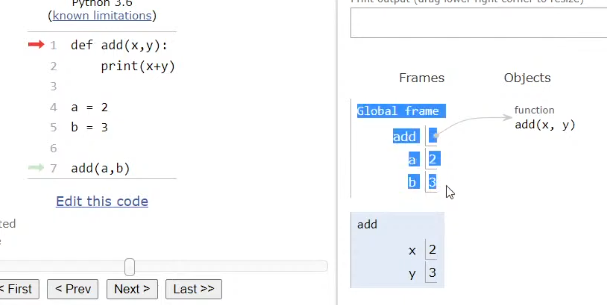
- In this program, there are two namespaces and two scope , a value cannot access the function directly and x cannot use outside the function

In [14]:
# local and gobal 
# global var
a =2 
def temp():
    # local var
    b = 3
    print(b)
temp()
print(a)

3
2


In [22]:
a = 2
def temp():
    a = 3
    print(a)

temp()
print(a)


3
2


In [34]:
# local and global-> local does not have but global has
a = 2
def temp():

    print(a) # LEGB rule 
print(a)
temp()

2
2


In [38]:
a = 2
def temp():
    a +=1
    print(a) # LEGB rule 
print(a)
temp()
# It will raised error: UnboundLocalError:, you can access global variable inside the function
# but you cannot Edit it

2


UnboundLocalError: cannot access local variable 'a' where it is not associated with a value

In [46]:
a =2 
def temp():
    global a # but this will change the origin variable so using it inside a function is not a good practice
    a += 1
    print(a)

temp()
print(a)
    

3
3


In [48]:
# local and global -> function parameter is 
def temp(z):
    print(z)
a = 5
temp(5)
print(a)

5
5


#### Built-in scope

In [51]:
import builtins
print(dir(builtins))

['ArithmeticError', 'AssertionError', 'AttributeError', 'BaseException', 'BaseExceptionGroup', 'BlockingIOError', 'BrokenPipeError', 'BufferError', 'BytesWarning', 'ChildProcessError', 'ConnectionAbortedError', 'ConnectionError', 'ConnectionRefusedError', 'ConnectionResetError', 'DeprecationWarning', 'EOFError', 'Ellipsis', 'EncodingWarning', 'EnvironmentError', 'Exception', 'ExceptionGroup', 'False', 'FileExistsError', 'FileNotFoundError', 'FloatingPointError', 'FutureWarning', 'GeneratorExit', 'IOError', 'ImportError', 'ImportWarning', 'IndentationError', 'IndexError', 'InterruptedError', 'IsADirectoryError', 'KeyError', 'KeyboardInterrupt', 'LookupError', 'MemoryError', 'ModuleNotFoundError', 'NameError', 'None', 'NotADirectoryError', 'NotImplemented', 'NotImplementedError', 'OSError', 'OverflowError', 'PendingDeprecationWarning', 'PermissionError', 'ProcessLookupError', 'RecursionError', 'ReferenceError', 'ResourceWarning', 'RuntimeError', 'RuntimeWarning', 'StopAsyncIteration', 'S

In [63]:
# Rename the built-in
L= [1, 2, 4]
max(L)
def max(): # rename the function
    print('helo')
print(max())
max(L) # LEGB -> Programm get max in global so it does not go to check for built-in               

TypeError: max() takes 0 positional arguments but 1 was given

In [65]:
# Enclosing 
def outer():
    def innner():
        print("your are in inner")
    innner()
    print("You are in outer")
outer()
print("You are in gobal")

your are in inner
You are in outer
You are in gobal


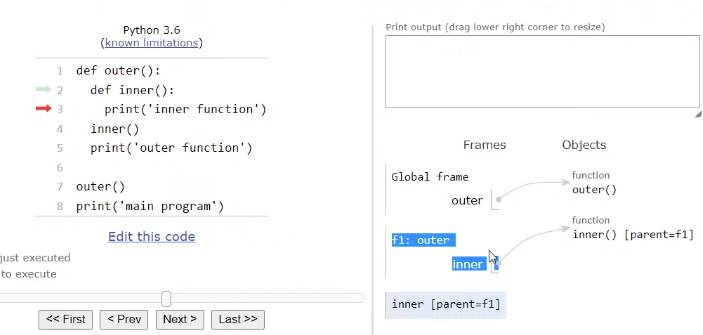
inner is the local scope , outer is the enclosing - non-local, and outside the function is the global and it follow LEGB rule

In [71]:
def outer():
    def inner():
        print(a)
    inner()
    print('outer function')
outer()
print('main program')

5
outer function
main program


In [75]:
# nonlocal keyword
def outer():
    a= 1
    def inner():
        nonlocal a
        a += 1
        print('inner a',a)
    inner()
    print('outer function', a)
outer()
print('main program')

inner a 2
outer function 2
main program


## What is a Decorator in Python?
- A decorator in python is the function that receives another function as input and adds some functionality(decoration) to and it and return it.
- This happen only because python function are 1st class citizen(example functon).
- A decorator in Python is a function that modifies another function without changing its structure. It allows you to add functionality (like logging, authentication, timing, etc.) to existing functions dynamically.
- There are 2 types of decorators available in python
- Built in decorators like @staticmethod, @classmethod, @abstractmethod and @ property
- User define a decorator that we programmers can create according to our needs

In [81]:
def modify(func, num): # decorator 
    return func(num)
def square(num): # input
    return num**2
modify(square, 2)


4

In [95]:
#simple example
def my_decorator(func):
    def wrapper():# added functionallity
        print('*************************************')
        func()
        print('*************************************')
    return wrapper
def hello():
    print('hello')
def display():
    print('Great to see you')
a = my_decorator(hello)
a()
b = my_decorator(display)
b()

*************************************
hello
*************************************
*************************************
Great to see you
*************************************


In [99]:
def outer():
    a = 5
    def inner():
        print(a)
    return inner # as the function returns the variable inside the function lost from memory
    # but as there is the nested function inside so it contains the reference of variable this property in python called closer
a = outer()
a()

5


In [101]:
# to make code small
def my_decorator(func):
    def wrapper():# added functionallity
        print('*************************************')
        func()
        print('*************************************')
    return wrapper

@my_decorator
def hello():
    print('hello')
hello()

*************************************
hello
*************************************


In [109]:
# Function that will tell the execution time of any function
import time
def timer(func):
    def wrapper(*arge):
        start = time.time()
        func(*arge)
        print('time taken by', func.__name__, time.time() -  start, 'sec')
    return wrapper

@timer
def hello():
    prin('hello world')

@timer
def hii():
    print('hello world')
    time.sleep(2)

@timer
def square(num):
    time.sleep(1)
    print( num**2)

@timer
def power(a, b):
    time.sleep(1)
    print(a**b)
square(2)
power(1, 4)

4
time taken by square 1.0011374950408936 sec
1
time taken by power 1.0015125274658203 sec


In [9]:
# A big problem 



def sanity_check(data_type):
    def outer_wrapper(func):
        def inner_wrapper(*args):
            if type(args[0]) == data_type:
                func(*args)
            else:
                raise TypeError("Data type not work")
        return inner_wrapper
    return outer_wrapper

@sanity_check(int)
def square(num):
    print(num**2)
square(7)

@sanity_check(str)
def greet(name):
    print('hello', name)
greet(5)


49


TypeError: Data type not work